In [36]:
import matplotlib.pyplot as plt

x = [2, 3, 4]

# Fitness 
f1 = [abs(i) for i in x] 
f2 = [i**2 for i in x] 
f3 = [2 * (i**2) for i in x] 
f4 = [(i**2) + 20 for i in x] 

#Probabilities
p1 = [i / sum(f1) for i in f1]
p2 = [i / sum(f2) for i in f2]
p3 = [i / sum(f3) for i in f3]
p4 = [i / sum(f4) for i in f4]




print(x)
print(p1)
print(p2)
print(p3)
print(p4)


[2, 3, 4]
[0.2222222222222222, 0.3333333333333333, 0.4444444444444444]
[0.13793103448275862, 0.3103448275862069, 0.5517241379310345]
[0.13793103448275862, 0.3103448275862069, 0.5517241379310345]
[0.2696629213483146, 0.3258426966292135, 0.4044943820224719]


In [29]:
import pandas as pd

# Table
df = pd.DataFrame({'x': x, 'f1': f1, 'p1': p1, 'f2': f2, 'p2': p2, 'f3': f3, 'p3': p3, 'f4': f4, 'p4': p4
})

print(df)

   x  f1        p1  f2        p2  f3        p3  f4        p4
0  2   2  0.222222   4  0.137931   8  0.137931  24  0.269663
1  3   3  0.333333   9  0.310345  18  0.310345  29  0.325843
2  4   4  0.444444  16  0.551724  32  0.551724  36  0.404494


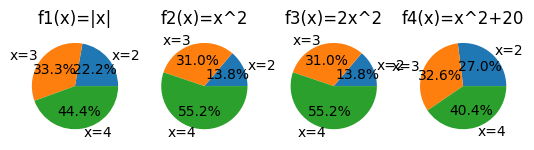

In [30]:

# Plot it - pie charts
plt.subplot(1, 4, 1)
plt.pie(p1, labels=["x=2", "x=3", "x=4"], autopct='%1.1f%%')
plt.title("f1(x)=|x|")

plt.subplot(1, 4, 2)
plt.pie(p2, labels=["x=2", "x=3", "x=4"], autopct='%1.1f%%')
plt.title("f2(x)=x^2")

plt.subplot(1, 4, 3)
plt.pie(p3, labels=["x=2", "x=3", "x=4"], autopct='%1.1f%%')
plt.title("f3(x)=2x^2")

plt.subplot(1, 4, 4)
plt.pie(p4, labels=["x=2", "x=3", "x=4"], autopct='%1.1f%%')
plt.title("f4(x)=x^2+20")

plt.show()

In [31]:
import random

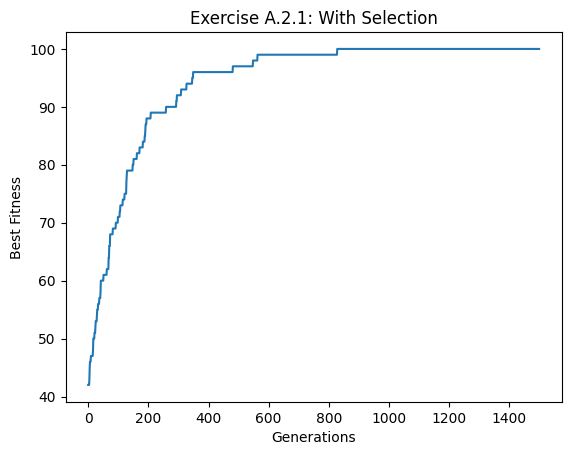

Final Fitness: 100


In [32]:

L = 100
mu = 1 / L
generations = 1500

# Step 1: Randomly generate bit sequence
x = [random.randint(0, 1) for _ in range(L)]
history_v1 = []

for gen in range(generations):
    # Step 2: Create copy and mutate (invert bits with probability mu)
    xm = [1 - bit if random.random() < mu else bit for bit in x]
    
    # Step 3: If xm is better (closer to 100 ones), replace x
    if sum(xm) > sum(x):
        x = xm
    
    history_v1.append(sum(x))

# Plotting the result
plt.plot(history_v1)
plt.title("Exercise A.2.1: With Selection")
plt.xlabel("Generations")
plt.ylabel("Best Fitness")
plt.show()

# Does it find the optimum? Yep
print(f"Final Fitness: {sum(x)}")

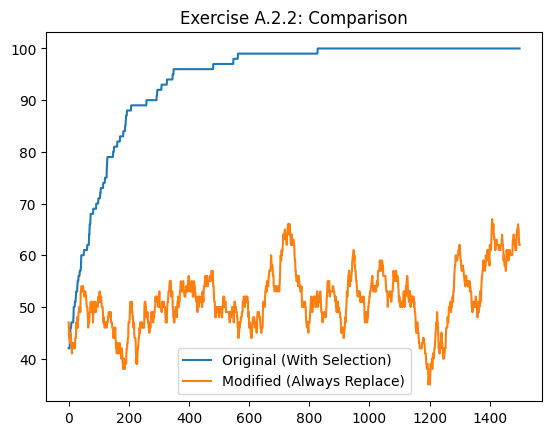

In [33]:
x_v2 = [random.randint(0, 1) for _ in range(L)]
history_v2 = []

for gen in range(generations):
    xm = [1 - bit if random.random() < mu else bit for bit in x_v2]
    
    # Step 3: Always replace
    x_v2 = xm
    history_v2.append(sum(x_v2))

# Plotting both
plt.plot(history_v1, label="Original (With Selection)")
plt.plot(history_v2, label="Modified (Always Replace)")
plt.legend()
plt.title("Exercise A.2.2: Comparison")
plt.show()

# What do you see? Modified sucks duh

In [34]:
# Multiple independent runs
num_runs = 10
all_runs_v1 = []

for run in range(num_runs):
    x = [random.randint(0, 1) for _ in range(L)]
    run_history = []
    for gen in range(generations):
        xm = [1 - bit if random.random() < mu else bit for bit in x]
        if sum(xm) > sum(x): x = xm
        run_history.append(sum(x))
    all_runs_v1.append(run_history)

print(f"Conducted {num_runs} independent runs to assess reliability.")

Conducted 10 independent runs to assess reliability.


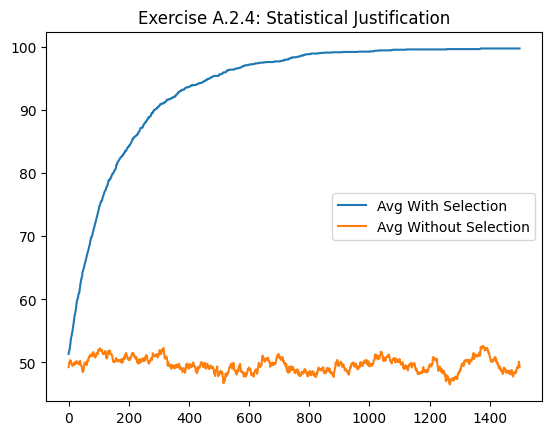

In [35]:
# To justify the difference, compare the average of multiple runs
def run_experiment(with_selection):
    averages = [0] * generations
    num_trials = 20
    for _ in range(num_trials):
        x = [random.randint(0, 1) for _ in range(L)]
        for gen in range(generations):
            xm = [1 - bit if random.random() < mu else bit for bit in x]
            if with_selection:
                if sum(xm) > sum(x): x = xm
            else:
                x = xm
            averages[gen] += sum(x) / num_trials
    return averages

avg_v1 = run_experiment(with_selection=True)
avg_v2 = run_experiment(with_selection=False)

plt.plot(avg_v1, label="Avg With Selection")
plt.plot(avg_v2, label="Avg Without Selection")
plt.title("Exercise A.2.4: Statistical Justification")
plt.legend()
plt.show()